In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
dfall = pd.read_csv("train_data.csv").set_index("id")
dfall.head()

,name,host_listings_count,host_total_listings_count,latitude,longitude,property_type,room_type,accommodates,bathrooms_text,bedrooms,...,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,price
id,,,,,,,,,,,,,,,,,,,,,
1051911,Tree Topz by Beach Stays,78.0,105.0,-33.642274,151.311018,Entire home,Entire home/apt,7,2 baths,3.0,...,15768.0,4.82,4.71,4.71,4.81,4.71,4.71,4.52,0.17,657.0
1125557,LUXURY BEACHFRONT APARTMENT,1.0,4.0,-34.048250,151.156220,Private room in rental unit,Private room,2,1 shared bath,1.0,...,1256.0,4.82,4.73,4.68,4.89,4.89,4.86,4.60,0.37,157.0
11156,An Oasis in the City,1.0,1.0,-33.867670,151.224970,Private room in rental unit,Private room,1,1 shared bath,1.0,...,0.0,4.59,4.76,4.30,4.80,4.76,4.82,4.71,1.04,65.0
44545,Sunny Darlinghurst Warehouse Apartment,1.0,1.0,-33.878880,151.214390,Entire loft,Entire home/apt,2,1 bath,1.0,...,3330.0,4.88,4.89,4.85,4.93,4.96,4.93,4.78,0.45,185.0
1054789,Cozy Lounge Room,3.0,3.0,-33.934830,151.145820,Private room in rental unit,Private room,1,1 bath,1.0,...,17085.0,4.89,4.81,4.85,4.87,4.92,4.88,4.83,9.44,67.0


In [15]:
dfall.info()

<class 'pandas.DataFrame'>
Index: 6517 entries, 1051911 to 1362677702473521257
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         6517 non-null   str    
 1   host_listings_count          6517 non-null   float64
 2   host_total_listings_count    6517 non-null   float64
 3   latitude                     6517 non-null   float64
 4   longitude                    6517 non-null   float64
 5   property_type                6517 non-null   str    
 6   room_type                    6517 non-null   str    
 7   accommodates                 6517 non-null   int64  
 8   bathrooms_text               6517 non-null   str    
 9   bedrooms                     6517 non-null   float64
 10  beds                         6517 non-null   float64
 11  amenities                    6517 non-null   str    
 12  availability_30              6517 non-null   int64  
 13  availability_

In [214]:
df = dfall.select_dtypes(include=["float64", "int64"])
# df = df.iloc[:, :10]
df["price"] = dfall["price"]

df.info()

<class 'pandas.DataFrame'>
Index: 6517 entries, 1051911 to 1362677702473521257
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   host_listings_count          6517 non-null   float64
 1   host_total_listings_count    6517 non-null   float64
 2   latitude                     6517 non-null   float64
 3   longitude                    6517 non-null   float64
 4   accommodates                 6517 non-null   int64  
 5   bedrooms                     6517 non-null   float64
 6   beds                         6517 non-null   float64
 7   availability_30              6517 non-null   int64  
 8   availability_90              6517 non-null   int64  
 9   number_of_reviews            6517 non-null   int64  
 10  number_of_reviews_ltm        6517 non-null   int64  
 11  number_of_reviews_l30d       6517 non-null   int64  
 12  availability_eoy             6517 non-null   int64  
 13  number_of_rev

In [237]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

xall, yall = df.iloc[:, :-1].to_numpy(), df.iloc[:, -1].to_numpy()

x, xt, y, yt = train_test_split(xall, yall, random_state=67)

# x = x[:2000]
# y = y[:2000]

sscaler = StandardScaler()
sscaler.fit(x)
x = sscaler.transform(x)
xt = sscaler.transform(xt)

print(x.shape)
print(y.shape)

(4887, 24)
(4887,)


UMAP(n_jobs=1, random_state=67, verbose=1)
Wed Apr  1 19:21:03 2026 Construct fuzzy simplicial set
Wed Apr  1 19:21:03 2026 Finding Nearest Neighbors
Wed Apr  1 19:21:03 2026 Building RP forest with 8 trees
Wed Apr  1 19:21:03 2026 NN descent for 12 iterations
	 1  /  12
	 2  /  12
	 3  /  12
	Stopping threshold met -- exiting after 3 iterations
Wed Apr  1 19:21:03 2026 Finished Nearest Neighbor Search
Wed Apr  1 19:21:03 2026 Construct embedding


Epochs completed:   1%|            5/500 [00:00]

	completed  0  /  500 epochs


Epochs completed:  11%| █▏         57/500 [00:01]

	completed  50  /  500 epochs


...

Epochs completed:  92%| █████████▏ 458/500 [00:11]

	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:12]


Wed Apr  1 19:21:16 2026 Finished embedding


<Axes: >

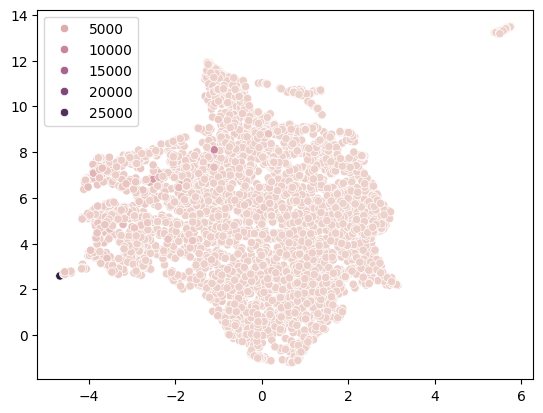

In [238]:
from umap import UMAP

tsne = UMAP(n_components=2, random_state=67, verbose=1)
xtsne = tsne.fit_transform(x)

sns.scatterplot(x=xtsne[:, 0], y=xtsne[:, 1], hue=y)

In [249]:
from sklearn.cluster import KMeans

n = 4

kmeans = KMeans(n_clusters=n, n_init=2, random_state=67)
kmeans.fit(x)

xlabel = kmeans.labels_
xs = [x[xlabel == i] for i in range(n)]
ys = [y[xlabel == i] for i in range(n)]

print("Each cluster size")
for i in range(n):
    print(f"Cluster {i}: {len(xs[i])}")

Each cluster size
Cluster 0: 2531
Cluster 1: 1034
Cluster 2: 363
Cluster 3: 959


In [257]:
from lightgbm import LGBMRegressor
from sklearn.pipeline import make_pipeline

pipe = []

for i in range(n):
    cur_pipe = make_pipeline(
        StandardScaler(),
        LGBMRegressor(random_state=67, n_estimators=50)
    )
    cur_pipe.fit(xs[i], ys[i])
    pipe.append(cur_pipe)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001150 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2401
[LightGBM] [Info] Number of data points in the train set: 2531, number of used features: 24
[LightGBM] [Info] Start training from score 243.847096
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000737 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2133
[LightGBM] [Info] Number of data points in the train set: 1034, number of used features: 24
[LightGBM] [Info] Start training from score 739.722437
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000456 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1221
[LightGBM] [Info] Number of data points in the train set: 363, number of used features: 24
[LightGBM] [Info] Start tra

In [258]:
def predict_single(a, kmeans, pipe):
    label = kmeans.predict([a])[0]

    return pipe[label].predict([a])[0]

def predict(a, kmeans, pipe):
    res = []
    for single_a in a:
        res.append(predict_single(single_a, kmeans, pipe))
    return res

In [259]:
from sklearn.metrics import mean_absolute_percentage_error
import warnings

warnings.filterwarnings("ignore")

predt = predict(xt, kmeans, pipe)
print(mean_absolute_percentage_error(yt, predt))

0.2744418620991278


In [268]:
dfsub = pd.read_csv("test_data.csv").set_index("id")
dfsub = dfsub.select_dtypes(include=["float64", "int64"])

xsub = dfsub.to_numpy()
xsub = sscaler.transform(xsub)

predsub = predict(xsub, kmeans, pipe)

In [275]:
submission = pd.Series(predsub, name="price", index=dfsub.index)
submission.to_csv("submission.csv")